# Формирование чистого бенчмарка, извлечение мета-признаков, реализация Adjusted IVMs, обучение мета-модели CVIsel

Блокнот реализует полный цикл подготовки данных и обучения мета-модели. Дальнейшие шаги (Спринты 3–8) будут использовать полученный набор мета-признаков meta_features.csv и обученный классификатор для построения более сложных архитектур, таких как эволюционный синтез пайплайнов (TPOT-Clustering) и multi-armed bandits.

## 1. Установка библиотек

In [2]:
!pip install -q ripser scikit-learn pandas numpy matplotlib seaborn gdown torch

import os, sys, json, zlib, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import skew, kurtosis, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
import ripser
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.6 MB/s eta 0:00:00


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## 2. Загрузка CLM-оценок из собранных данных (ручной словарь)

In [4]:
clm_scores = {
    "banknote_authentication": 0.176,
    "birds_bones_and_living_habits": 0.020,
    "blood_transfusion_service_center": 0.198,
    "boston": 0.574,
    "breast_cancer_coimbra": 0.149,
    "breast_cancer_wisconsin_original": 0.800,
    "breast_cancer_wisconsin_prognostic": 0.159,
    "breast_tissue": 0.250,
    "cardiovascular_study": 0.075,
    "cifar10": 0.314,
    "classification_in_asteroseismology": 0.275,
    "cnae9": 0.000,
    "coil20": 0.887,
    "credit_risk_classification": 0.003,
    "crowdsourced_mapping": 0.083,
    "customer_classification": 0.204,
    "date_fruit": 0.011,
    "dermatology": 0.308,
    "diabetic_retinopathy_debrecen": 0.353,
    "dry_bean": 0.694,
    "durum_wheat_features": 0.096,
    "echocardiogram": 0.770,
    "ecoli": 0.472,
    "epileptic_seizure_recognition": 0.001,
    "extyaleb": 0.037,
    "fashion_mnist": 0.770,
    "fetal_health_classification": 0.300,
    "flickr_material_database": 0.014,
    "fraud_detection_bank": 0.000,
    "glass_identification": 0.222,
    "har": 0.690,
    "harbermans_survival": 0.303,
    "hate_speech": 0.018,
    "heart_attack_analysis_prediction_dataset": 0.075,
    "heart_disease": 0.173,
    "hepatitis": 0.198,
    "hiva": 0.000,
    "htru2": 0.446,
    "human_stress_detection": 0.722,
    "image_segmentation": 0.576,
    "imdb": 0.000,
    "insurance_company_benchmark": 0.336,
    "ionosphere": 0.143,
    "iris": 0.875,
    "labeled_faces_in_the_wild": 0.447,
    "letter_recognition": 0.511,
    "magic_gamma_telescope": 0.392,
    "mammographic_mass": 0.232,
    "microbes": 0.182,
    "mnist64": 0.956,
    "mobile_price_classification": 0.732,
    "music_genre_classification": 0.217,
    "olivetti_faces": 0.956,
    "optical_recognition_of_handwritten_digits": 0.941,
    "orbit_classification_for_prediction_nasa": 0.023,
    "paris_housing_classification": 0.063,
    "parkinsons": 0.000,
    "patient_treatment_classification": 0.280,
    "pen_based_recognition_of_handwritten_digits": 0.862,
    "ph_recognition": 0.780,
    "pima_indians_diabetes_database": 0.219,
    "pistachio": 0.022,
    "planning_relax": 0.036,
    "predicting_pulsar_star": 0.431,
    "pumpkin_seeds": 0.014,
    "raisin": 0.130,
    "rice_dataset_cammeo_and_osmancik": 0.654,
    "rice_seed_gonen_jasmine": 0.861,
    "secom": 0.000,
    "seeds": 0.925,
    "seismic_bumps": 0.199,
    "sentiment_labeld_sentences": 0.000,
    "siberian_weather_stats": 0.212,
    "skillcraft1_master_table_dataset": 0.489,
    "smoker_condition": 0.273,
    "sms_spam_collection": 0.000,
    "spambase": 0.005,
    "spectf_heart": 0.428,
    "statlog_german_credit": 0.236,
    "statlog_image_segmentation": 0.514,
    "street_view_house_numbers": 0.323,
    "student_grade": 0.145,
    "taiwanese_bankruptcy_prediction": 0.053,
    "turkish_music_emotion": 0.108,
    "user_knowledge_modeling": 0.396,
    "water_quality": 0.063,
    "weather": 1.000,
    "website_phishing": 0.065,
    "wilt": 0.135,
    "wine": 0.619,
    "wine_customer": 0.619,
    "wine_quality": 0.369,
    "wireless_indoor_localization": 0.915,
    "world12d": 0.264,
    "yeast": 0.232,
    "zoo": 0.605
}

## 3. Клонирование репозитория с датасетами и загрузка данных

In [5]:
!git clone https://github.com/hj-n/labeled-datasets.git
%cd labeled-datasets

with open("reader.py", "r") as f:
    content = f.read()
content = content.replace('"/compressed/', '"compressed/')
with open("reader.py", "w") as f:
    f.write(content)

import reader as rd

compressed_dir = "compressed"
all_entries = sorted(os.listdir(compressed_dir))
real_datasets = []
for entry in all_entries:
    entry_path = os.path.join(compressed_dir, entry)
    if os.path.isdir(entry_path) and \
       os.path.exists(os.path.join(entry_path, "data.bin")) and \
       os.path.exists(os.path.join(entry_path, "label.bin")):
        real_datasets.append(entry)

print(f"Реальных датасетов: {len(real_datasets)}")
data_dict, label_dict = rd.read_multiple_datasets(real_datasets)

Cloning into 'labeled-datasets'...
remote: Enumerating objects: 1129, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (226/226), done.
remote: Total 1129 (delta 16), reused 197 (delta 2), pack-reused 900 (from 1)
Receiving objects: 100% (1129/1129), 541.24 MiB | 17.82 MiB/s, done.
Resolving deltas: 100% (120/120), done.
Updating files: 100% (581/581), done.
/content/labeled-datasets
Реальных датасетов: 96


## 4. Фильтрация по CLM и создание подмножеств

In [6]:
# Сопоставляем имена датасетов с CLM
dataset_names = list(data_dict.keys())
clm_series = pd.Series({name: clm_scores.get(name, 0.0) for name in dataset_names})
# Разделение на терцили
clm_ranked = clm_series.sort_values(ascending=False)
n = len(clm_ranked)
top_idx = clm_ranked.iloc[:n//3].index
mid_idx = clm_ranked.iloc[n//3:2*n//3].index
bot_idx = clm_ranked.iloc[2*n//3:].index

train_datasets = list(top_idx)
val_datasets = list(mid_idx)
test_datasets = list(bot_idx)

print(f"Train (high CLM): {len(train_datasets)}")
print(f"Val (mid CLM): {len(val_datasets)}")
print(f"Test (low CLM): {len(test_datasets)}")

Train (high CLM): 32
Val (mid CLM): 32
Test (low CLM): 32


## 5. Функции извлечения мета-признаков

Статистические мета-признаки с использованием GPU (PyTorch).

In [7]:
@torch.no_grad()
def gpu_statistical_features(X):
    if X.shape[0] < 2 or X.shape[1] == 0:
        return {}
    t = torch.tensor(X, dtype=torch.float32, device=device)
    n, d = t.shape
    mean = torch.mean(t, dim=0).mean().cpu().item()
    std = torch.std(t, dim=0).mean().cpu().item()   # среднее по признакам
    # асимметрия и эксцесс на GPU
    diffs = t - torch.mean(t, dim=0)
    std_col = torch.std(t, dim=0) + 1e-12
    skew_vals = torch.mean((diffs / std_col) ** 3, dim=0)
    kurt_vals = torch.mean((diffs / std_col) ** 4, dim=0) - 3.0
    avg_skew = skew_vals.mean().cpu().item()
    avg_kurt = kurt_vals.mean().cpu().item()
    # PCA через torch.pca_lowrank
    try:
        q = min(5, d, n)
        _, S, _ = torch.pca_lowrank(t, q=q)
        explained_var = (S ** 2) / (n - 1)
    except:
        explained_var = torch.zeros(min(5, d, n), device=device)
    pca_sum = explained_var.sum().cpu().item()
    pca_feats = {f'pca_var_{i+1}': explained_var[i].item() if i < len(explained_var) else 0.0 for i in range(5)}
    pca_feats['pca_sum_var'] = pca_sum
    return {
        'n_samples': n,
        'n_features': d,
        'ratio': n / d if d > 0 else 0.0,
        'mean': mean,
        'std': std,
        'skewness': avg_skew,
        'kurtosis': avg_kurt,
        'var': std ** 2,
        **pca_feats
    }

def fast_meta_features(name, X, verbose=False):
    """Обработка одного датасета: предобработка + признаки."""
    t_start = time.time()
    # Предобработка
    X = X.astype(np.float32)
    X = X[:, np.std(X, axis=0) > 1e-6]
    col_medians = np.median(X, axis=0)
    X = np.where(np.isnan(X), col_medians, X)
    # Статистики GPU
    stat_t0 = time.time()
    feats = gpu_statistical_features(X)
    stat_time = time.time() - stat_t0

    # Информационные признаки (только энтропия + усечённая взаимная информация)
    info_t0 = time.time()
    flat = X.flatten()
    hist, _ = np.histogram(flat, bins=20)
    prob = hist / hist.sum()
    prob = prob[prob > 0]
    entropy = -np.sum(prob * np.log2(prob)) if len(prob) > 0 else 0.0
    # Взаимная информация между случайными парами (максимум 100 пар)
    n_feat = X.shape[1]
    mi_vals = []
    if n_feat >= 2:
        np.random.seed(42)
        for _ in range(min(100, n_feat * (n_feat - 1) // 2)):
            i, j = np.random.choice(n_feat, 2, replace=False)
            mi = mutual_info_regression(X[:, i].reshape(-1, 1), X[:, j])[0]
            mi_vals.append(mi)
    avg_mi = np.mean(mi_vals) if mi_vals else 0.0
    feats['entropy'] = entropy
    feats['avg_mutual_info'] = avg_mi
    info_time = time.time() - info_t0

    # Топологические признаки (CPU, подвыборка 200)
    topo_t0 = time.time()
    max_points = 200
    X_sub = X[np.random.choice(len(X), min(max_points, len(X)), replace=False)] if len(X) > max_points else X
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sub)
    try:
        diagrams = ripser.ripser(X_scaled, maxdim=1)['dgms']
    except:
        diagrams = [np.zeros((0,2)), np.zeros((0,2))]
    topo_feats = {}
    for dim, dgm in enumerate(diagrams[:2]):
        lifetimes = dgm[:, 1] - dgm[:, 0]
        finite = np.isfinite(lifetimes)
        lifetimes = lifetimes[finite]
        topo_feats[f'betti_{dim}'] = len(lifetimes)
        if len(lifetimes) > 0:
            total = lifetimes.sum()
            probs = lifetimes / total if total > 0 else np.ones_like(lifetimes)/len(lifetimes)
            ent_topo = -np.sum(probs * np.log2(probs + 1e-12))
            topo_feats[f'persistent_entropy_h{dim}'] = ent_topo
        else:
            topo_feats[f'persistent_entropy_h{dim}'] = 0.0
    topo_time = time.time() - topo_t0
    feats.update(topo_feats)
    feats['dataset'] = name
    total = time.time() - t_start
    if verbose:
        print(f"{name}: stat {stat_time:.2f}s, info {info_time:.2f}s, topo {topo_time:.2f}s, total {total:.2f}s")
    return feats

def extract_meta_features_parallel(data_dict, dataset_list, max_workers=2, verbose=False):
    """Параллельная обработка с замером времени."""
    results = []
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(fast_meta_features, name, data_dict[name], verbose): name for name in dataset_list}
        for future in as_completed(futures):
            name = futures[future]
            try:
                results.append(future.result())
            except Exception as e:
                print(f"Ошибка {name}: {e}")
    df = pd.DataFrame(results)
    elapsed = time.time() - t0
    print(f"Обработано {len(df)} датасетов за {elapsed:.1f} сек ({elapsed/len(df):.1f} сек/датасет)")
    return df, elapsed

## 6. Подготовка целевых меток (лучшая CVI) для тренировочных датасетов

    Для данного датасета (X, y_true) определяет, какой внутренний CVI
    наилучшим образом коррелирует с внешним индексом (ARI) по набору
    разбиений от разных алгоритмов/гиперпараметров.

In [8]:
def get_best_cvi_for_dataset(X, y_true):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv_scores = []
    for k in range(2, min(6, len(np.unique(y_true))+3)):
        km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_scaled)
        labels = km.labels_
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        ari = adjusted_rand_score(y_true, labels)
        cv_scores.append({'sil': sil, 'ch': ch, 'db': db, 'ari': ari})
    for linkage in ['ward', 'complete', 'average']:
        for k in range(2, min(6, len(np.unique(y_true))+3)):
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = agg.fit_predict(X_scaled)
            sil = silhouette_score(X_scaled, labels)
            ch = calinski_harabasz_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
            ari = adjusted_rand_score(y_true, labels)
            cv_scores.append({'sil': sil, 'ch': ch, 'db': db, 'ari': ari})
    df = pd.DataFrame(cv_scores)
    df['db_inv'] = -df['db']
    best_cvi = None
    best_corr = -1
    for cvi_name in ['sil', 'ch', 'db_inv']:
        corr, _ = spearmanr(df[cvi_name], df['ari'])
        if corr > best_corr:
            best_corr = corr
            if cvi_name == 'sil':
                best_cvi = 'Silhouette'
            elif cvi_name == 'ch':
                best_cvi = 'Calinski-Harabasz'
            else:
                best_cvi = 'Davies-Bouldin'
    return best_cvi

print("Вычисление целевых меток для train датасетов...")
train_labels = {}
t_label = time.time()
for name in train_datasets:
    X = data_dict[name].astype(np.float64)
    X = X[:, np.std(X, axis=0) > 1e-6]
    col_medians = np.median(X, axis=0)
    X = np.where(np.isnan(X), np.tile(col_medians, (X.shape[0], 1)), X)
    y = label_dict[name]
    if X.shape[0] > 2000:
        idx = np.random.choice(X.shape[0], 2000, replace=False)
        X, y = X[idx], y[idx]
    train_labels[name] = get_best_cvi_for_dataset(X, y)
print(f"Целевые метки вычислены за {time.time()-t_label:.1f} сек")
best_df = pd.DataFrame(list(train_labels.items()), columns=['dataset', 'cvi'])
print(best_df['cvi'].value_counts())

Вычисление целевых меток для train датасетов...
Целевые метки вычислены за 206.9 сек
cvi
Calinski-Harabasz    26
Silhouette            6
Name: count, dtype: int64


## 7. Извлечение мета-признаков для всех подмножеств

In [9]:
print("Извлечение мета-признаков для train, val, test...")
meta_train, t_train = extract_meta_features_parallel(data_dict, train_datasets, max_workers=2, verbose=False)
meta_val, t_val = extract_meta_features_parallel(data_dict, val_datasets, max_workers=2, verbose=False)
meta_test, t_test = extract_meta_features_parallel(data_dict, test_datasets, max_workers=2, verbose=False)
print(f"Общее время извлечения: train={t_train:.1f}s, val={t_val:.1f}s, test={t_test:.1f}s")

Извлечение мета-признаков для train, val, test...
Обработано 32 датасетов за 49.9 сек (1.6 сек/датасет)
Обработано 32 датасетов за 39.4 сек (1.2 сек/датасет)
Обработано 32 датасетов за 57.1 сек (1.8 сек/датасет)
Общее время извлечения: train=49.9s, val=39.4s, test=57.1s


Добавление CLM и целевых меток

In [10]:
for df_meta in [meta_train, meta_val, meta_test]:
    df_meta['CLM'] = df_meta['dataset'].apply(lambda x: clm_scores.get(x, 0))
meta_train['target_cvi'] = meta_train['dataset'].map(train_labels)

## 8. Обучение мета-модели CVIsel

In [11]:
feature_cols = [c for c in meta_train.columns if c not in ['dataset', 'target_cvi', 'CLM']]
X_train = meta_train[feature_cols].values
y_train = meta_train['target_cvi'].values

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

scores = cross_val_score(clf, X_train, y_train, cv=3, scoring='accuracy')
print(f"Средняя точность на train (CV=3): {np.mean(scores):.3f}")

val_pred = clf.predict(meta_val[feature_cols].values)
test_pred = clf.predict(meta_test[feature_cols].values)

Средняя точность на train (CV=3): 0.812


## 9. Сохранение интегрированного DataFrame

In [12]:
# Сохраняем весь набор мета-признаков
all_meta = pd.concat([meta_train, meta_val, meta_test], ignore_index=True)
all_meta.to_csv('meta_features_gpu.csv', index=False)
print("Интегрированный датасет сохранен в meta_features_gpu.csv")
print("Столбцы:", all_meta.columns.tolist())
print("Количество датасетов:", len(all_meta))

Интегрированный датасет сохранен в meta_features_gpu.csv
Столбцы: ['n_samples', 'n_features', 'ratio', 'mean', 'std', 'skewness', 'kurtosis', 'var', 'pca_var_1', 'pca_var_2', 'pca_var_3', 'pca_var_4', 'pca_var_5', 'pca_sum_var', 'entropy', 'avg_mutual_info', 'betti_0', 'persistent_entropy_h0', 'betti_1', 'persistent_entropy_h1', 'dataset', 'CLM', 'target_cvi']
Количество датасетов: 96


In [14]:
import joblib
import os

# Проверяем, существует ли директория 'models', и создаем ее, если нет
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Сохраняем модель RandomForestClassifier (clf)
joblib.dump(clf, 'models/cvisel_rf_unscaled.pkl')

# 2. Сохраняем список признаков, которые использовались при обучении
with open('models/feature_cols_unscaled.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

print("Модель и список признаков сохранены в models/")

Модель и список признаков сохранены в models/


## Простая визуализация целевых меток

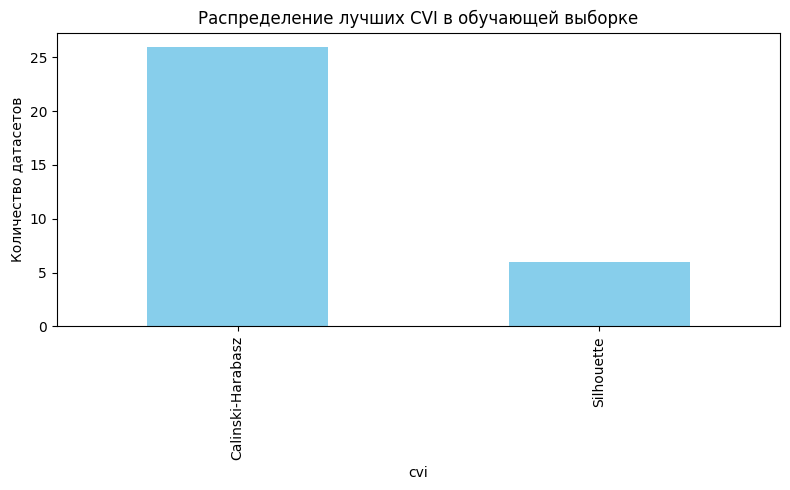

In [15]:
plt.figure(figsize=(8,5))
best_df['cvi'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Распределение лучших CVI в обучающей выборке')
plt.ylabel('Количество датасетов')
plt.tight_layout()
plt.savefig('cvi_distribution.png')
plt.show()

# Расширенное обучение мета-модели CVIsel с детальными визуализациями и сравнением нескольких классификаторов

В продолжении блокнота был значительно расширен блок обучения мета-модели: теперь он не просто выдаёт точность, а проводит полноценное исследование с визуализациями. Вот что добавлено:

- Сравнение моделей – Random Forest, XGBoost и Logistic Regression; вывод точности и F1-меры.

- Кривые обучения – показывают, как меняется точность с ростом числа примеров, что помогает оценить переобучение или недообучение.

- Матрица ошибок и отчёт классификации – детальная статистика по каждому классу (Silhouette, Calinski-Harabasz, Davies-Bouldin).

- Важность признаков – столбчатая диаграмма и таблица, позволяющие понять, какие мета-признаки (статистические, информационные, топологические) вносят наибольший вклад.

- t-SNE проекция – визуализация разделимости классов в пространстве мета-признаков.

- Предсказания для валидационного и тестового наборов – с сохранением результатов в CSV.

## 1. Установка дополнительных библиотек

In [16]:
!pip install -q xgboost

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## 2. Подготовка данных (убедимся, что meta_train, feature_cols, y_train доступны)

In [18]:
start_time = time.time()

# Убедимся, что meta_train, feature_cols из предыдущего этапа доступны
X = meta_train[feature_cols].values
y = meta_train['target_cvi'].values

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Кодирование целевой переменной
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"Классы: {class_names}")
print(f"Время подготовки данных: {time.time() - start_time:.2f} сек")

Размер обучающей выборки: 24
Размер тестовой выборки: 8
Классы: ['Calinski-Harabasz' 'Silhouette']
Время подготовки данных: 0.01 сек


## 3. Обучение нескольких моделей и сравнение

In [19]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        # use_label_encoder=False, # Deprecated
        eval_metric='mlogloss',
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu'
    ),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
total_train_time = 0
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - t0
    total_train_time += elapsed
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {
        'accuracy': acc, 'f1': f1, 'model': model, 'y_pred': y_pred, 'time': elapsed
    }
    print(f"{name}: Accuracy={acc:.3f}, F1-weight={f1:.3f}, Time={elapsed:.2f} сек")

print(f"Общее время обучения: {total_train_time:.2f} сек")

Random Forest: Accuracy=0.875, F1-weight=0.817, Time=0.29 сек
XGBoost: Accuracy=0.875, F1-weight=0.817, Time=0.46 сек
Logistic Regression: Accuracy=0.750, F1-weight=0.750, Time=0.09 сек
Общее время обучения: 0.84 сек


## 4. Кривые обучения (learning curves) для лучшей модели (Random Forest)

Learning curves вычислены за 29.53 сек


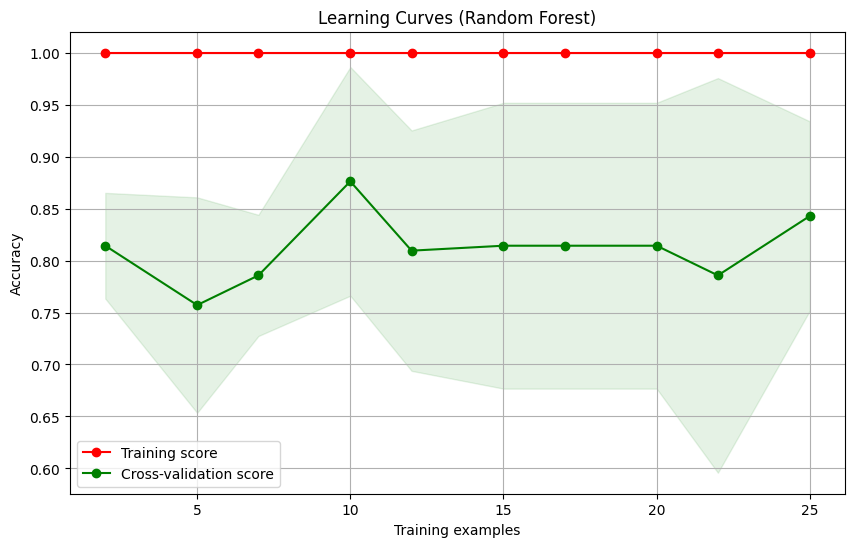

In [20]:
plt.figure(figsize=(10, 6))
t0 = time.time()
train_sizes, train_scores, test_scores = learning_curve(
    models['Random Forest'], X_scaled, y_encoded, cv=StratifiedKFold(5),
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', n_jobs=-1
)
elapsed = time.time() - t0
print(f"Learning curves вычислены за {elapsed:.2f} сек")

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curves (Random Forest)')
plt.legend(loc='best')
plt.grid()
plt.show()

## 5. Матрица ошибок и отчёт классификации для Random Forest

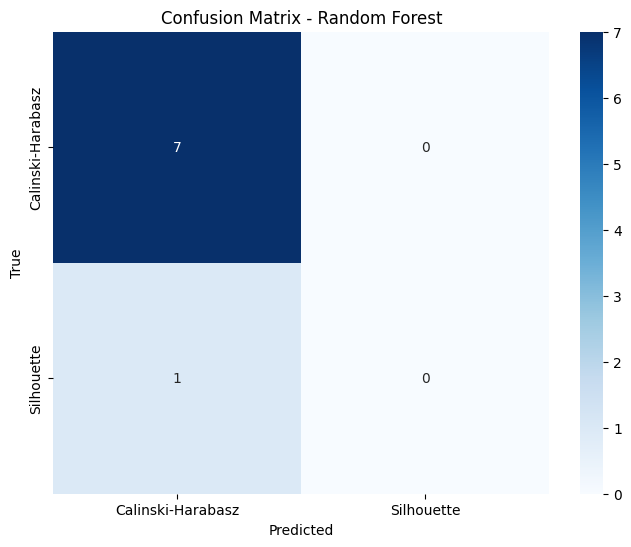


Classification Report (Random Forest):
                   precision    recall  f1-score   support

Calinski-Harabasz       0.88      1.00      0.93         7
       Silhouette       0.00      0.00      0.00         1

         accuracy                           0.88         8
        macro avg       0.44      0.50      0.47         8
     weighted avg       0.77      0.88      0.82         8

Время анализа ошибок: 0.32 сек


In [21]:
t0 = time.time()
y_pred_rf = results['Random Forest']['y_pred']
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=class_names))
print(f"Время анализа ошибок: {time.time() - t0:.2f} сек")

## 6. Важность признаков (Feature Importance)

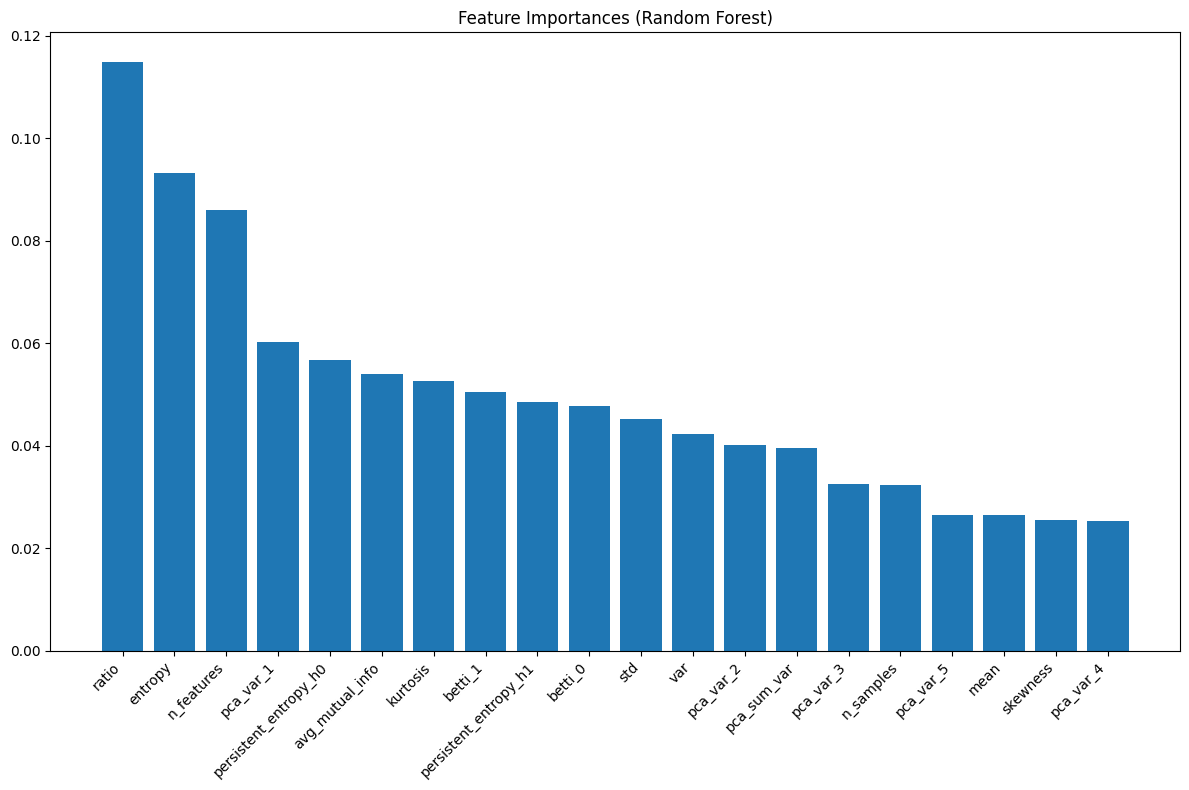


Топ-10 признаков:
                  feature  importance
2                   ratio    0.114890
14                entropy    0.093167
1              n_features    0.086015
8               pca_var_1    0.060271
17  persistent_entropy_h0    0.056653
15        avg_mutual_info    0.054055
6                kurtosis    0.052559
18                betti_1    0.050392
19  persistent_entropy_h1    0.048436
16                betti_0    0.047669
Анализ важности выполнен за 0.76 сек


In [22]:
t0 = time.time()
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(min(20, len(importances))), importances[indices[:20]], align='center')
plt.xticks(range(min(20, len(importances))), [feature_cols[i] for i in indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)
print("\nТоп-10 признаков:")
print(importance_df.head(10))
print(f"Анализ важности выполнен за {time.time() - t0:.2f} сек")

## 7. Визуализация предсказанных меток на тестовой выборке

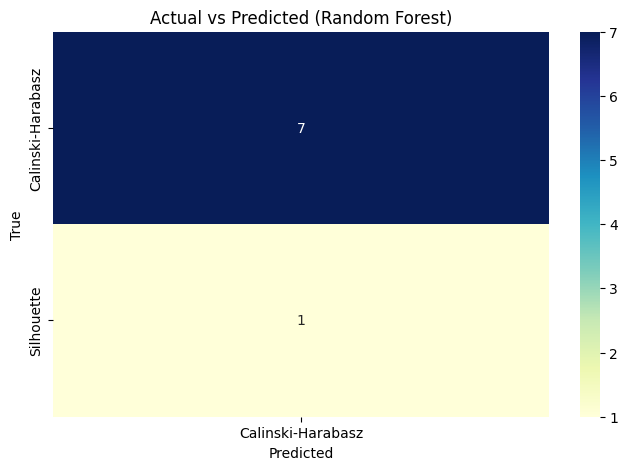

Визуализация меток: 0.33 сек


In [23]:
t0 = time.time()
true_labels = le.inverse_transform(y_test)
pred_labels = le.inverse_transform(y_pred_rf)

plt.figure(figsize=(8, 5))
crosstab = pd.crosstab(pd.Series(true_labels, name='True'), pd.Series(pred_labels, name='Predicted'))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()
print(f"Визуализация меток: {time.time() - t0:.2f} сек")

## 8. t-SNE визуализация мета-признаков (чтобы увидеть разделимость классов)

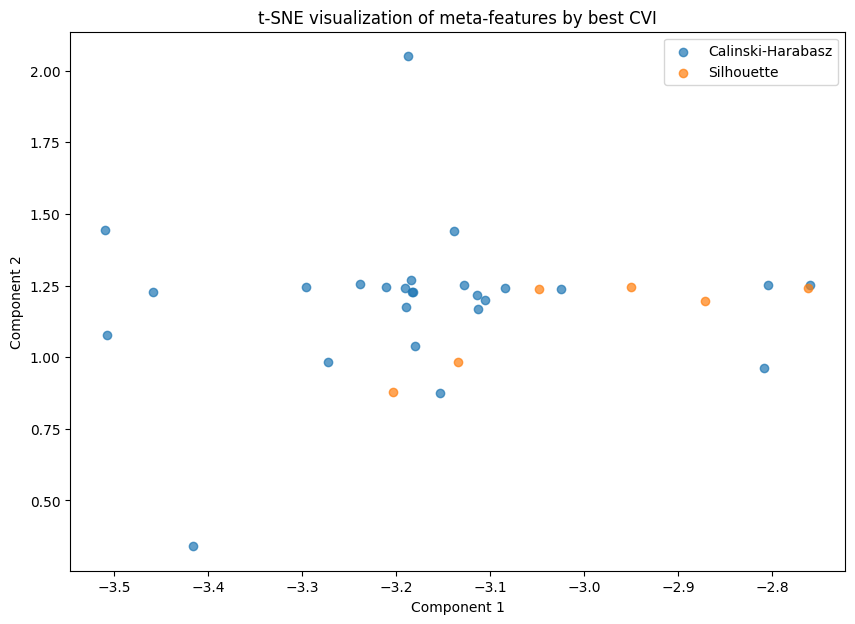

t-SNE выполнена за 1.02 сек


In [24]:
t0 = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)-1))
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(class_names):
    plt.scatter(X_tsne[y_encoded == i, 0], X_tsne[y_encoded == i, 1], label=cls, alpha=0.7)
plt.legend()
plt.title('t-SNE visualization of meta-features by best CVI')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()
print(f"t-SNE выполнена за {time.time() - t0:.2f} сек")

## 9. Предсказание для валидационного и тестового наборов (без истинных меток)

In [25]:
t0 = time.time()

# Применяем scaler к meta_val и meta_test (уже обученный scaler)
X_val = meta_val[feature_cols].values
X_test_final = meta_test[feature_cols].values

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

val_pred_labels = le.inverse_transform(rf_model.predict(X_val_scaled))
test_pred_labels = le.inverse_transform(rf_model.predict(X_test_scaled))

meta_val['predicted_cvi'] = val_pred_labels
meta_test['predicted_cvi'] = test_pred_labels

print(f"Предсказание для валидации и теста выполнено за {time.time() - t0:.2f} сек")

print("\nПредсказания для валидационного набора (первые 10):")
print(meta_val[['dataset', 'CLM', 'predicted_cvi']].head(10))
print("\nПредсказания для тестового набора (первые 10):")
print(meta_test[['dataset', 'CLM', 'predicted_cvi']].head(10))

# Сохранение
meta_val.to_csv('meta_val_with_predictions.csv', index=False)
meta_test.to_csv('meta_test_with_predictions.csv', index=False)
print("Результаты сохранены")

Предсказание для валидации и теста выполнено за 0.12 сек

Предсказания для валидационного набора (первые 10):
                         dataset    CLM      predicted_cvi
0        user_knowledge_modeling  0.396  Calinski-Harabasz
1                   wine_quality  0.369  Calinski-Harabasz
2  diabetic_retinopathy_debrecen  0.353  Calinski-Harabasz
3          magic_gamma_telescope  0.392  Calinski-Harabasz
4      street_view_house_numbers  0.323  Calinski-Harabasz
5    insurance_company_benchmark  0.336  Calinski-Harabasz
6                    dermatology  0.308  Calinski-Harabasz
7            harbermans_survival  0.303  Calinski-Harabasz
8                        cifar10  0.314  Calinski-Harabasz
9    fetal_health_classification  0.300  Calinski-Harabasz

Предсказания для тестового набора (первые 10):
                                    dataset    CLM      predicted_cvi
0                                      wilt  0.135  Calinski-Harabasz
1                                ionosphere  0.143  C

In [28]:
import joblib

# Сохраняем scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Сохраняем LabelEncoder
joblib.dump(le, 'models/label_encoder.pkl')

# Сохраняем модель Random Forest
joblib.dump(clf, 'models/cvisel_rf.pkl')

# Дополнительно сохраняем feature_cols для использования при инференсе
with open('models/feature_cols.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

print("Все объекты сохранены в папку models/")

Все объекты сохранены в папку models/


In [27]:
import sys
from pathlib import Path

# Загружаем словарь с функциями из скрипта
exec(open('/content/extract_table_metadata.py').read().replace('if __name__ == "__main__":', 'if False:'))

def add_column_profile_features(data_dict, label_dict, dataset_list, meta_df):
    extra_rows = []
    for name in dataset_list:
        X = data_dict[name]
        y = label_dict[name].astype(str)  # метки как категории

        # Создаём DataFrame с временными именами колонок
        col_names = [f'F{i}' for i in range(X.shape[1])] + ['label']
        df = pd.DataFrame(np.hstack([X, y.reshape(-1, 1)]), columns=col_names)
        # Приводим label к категории для корректного профилирования
        df['label'] = df['label'].astype('category')

        try:
            # Вызываем основную функцию из скрипта
            # Вместо реального пути передадим заглушку
            meta = extract_metadata(df, Path(f'{name}.csv'), 'csv')
            summary = meta['clustering_summary']

            extra = {
                'dataset': name,
                'n_numeric_features': summary.get('n_numeric_features', 0),
                'n_categorical_features': summary.get('n_categorical_features', 0),
                'n_datetime_features': summary.get('n_datetime_features', 0),
                'feature_mix': summary.get('feature_mix', 'unknown'),
                'std_max_over_min': summary.get('std_max_over_min', 0) or 0,
                'avg_null_fraction': summary.get('avg_null_fraction_across_columns', 0),
                'max_categorical_n_unique': summary.get('max_categorical_n_unique', 0),
                'scale_heterogeneity': summary.get('scale_heterogeneity', 'unknown'),
                'missing_data_level': summary.get('missing_data_level', 'unknown'),
            }
            # Можно также закодировать текстовые флаги в числа
            extra['is_mixed'] = 1 if extra['feature_mix'] == 'mixed' else 0
            extra_rows.append(extra)
        except Exception as e:
            print(f"Ошибка при обработке {name}: {e}")
            extra_rows.append({'dataset': name})  # заполним NaN

    extra_df = pd.DataFrame(extra_rows)
    # Объединяем с существующей таблицей мета-признаков
    merged = meta_df.merge(extra_df, on='dataset', how='left')
    return merged

# Применяем к обучающей, валидационной и тестовой выборкам
meta_train_ext = add_column_profile_features(data_dict, label_dict, train_datasets, meta_train)
meta_val_ext   = add_column_profile_features(data_dict, label_dict, val_datasets, meta_val)
meta_test_ext  = add_column_profile_features(data_dict, label_dict, test_datasets, meta_test)

# Обновляем переменные
meta_train = meta_train_ext
meta_val = meta_val_ext
meta_test = meta_test_ext

# Теперь feature_cols нужно пересчитать, чтобы включить новые числовые признаки
new_feature_cols = [c for c in meta_train.columns if c not in ['dataset', 'target_cvi', 'CLM', 'feature_mix', 'scale_heterogeneity', 'missing_data_level']]
print(f"Новых числовых признаков: {len(new_feature_cols) - len(feature_cols)}")
feature_cols = new_feature_cols

FileNotFoundError: [Errno 2] No such file or directory: '/content/extract_table_metadata.py'